### Exploration business - movies_enriched
- Objectif : visualiser les tendances budget / revenue / ROI par genre, année, 
- et identifier les realisateurs les plus rentables.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/processed/movies_enriched.parquet")
df["genres_list"] = df["genres_list"].str.split("|")
df["cast_list"] = df["cast_list"].str.split("|")

print(df.shape)
df.head()

(3002, 23)


,movieId,title_movielens,genres_movielens,imdbId,tmdbId,tmdb_id,title,budget,revenue,release_date,...,vote_average,vote_count,production_companies,director,release_year,n_genres,n_cast_listed,roi,genres_list,cast_list
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862,862,Toy Story,30000000.0,962301978.0,1995-11-22,...,7.988,20516,[Pixar],John Lasseter,1995,4,10,31.076733,"[Family, Comedy, Animation, Adventure]","[Tom Hanks, Tim Allen, Don Rickles, Jim Varney..."
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844,8844,Jumanji,65000000.0,262821940.0,1995-12-15,...,7.250,11552,"[TriStar Pictures, Interscope Communications, ...",Joe Johnston,1995,3,10,3.043414,"[Adventure, Fantasy, Family]","[Kirsten Dunst, Bradley Pierce, Robin Williams..."
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602,15602,Grumpier Old Men,25000000.0,71518503.0,1995-12-22,...,6.467,441,"[Lancaster Gate, Warner Bros. Pictures]",Howard Deutch,1995,2,10,1.860740,"[Romance, Comedy]","[Walter Matthau, Jack Lemmon, Ann-Margret, Sop..."
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357,31357,Waiting to Exhale,16000000.0,81452156.0,1995-12-22,...,6.200,213,[20th Century Fox],Forest Whitaker,1995,3,10,4.090760,"[Comedy, Drama, Romance]","[Whitney Houston, Angela Bassett, Loretta Devi..."
4,5,Father of the Bride Part II (1995),Comedy,113041,11862,11862,Father of the Bride Part II,NaN,76594107.0,1995-12-08,...,6.271,837,"[Touchstone Pictures, Sandollar Productions]",Charles Shyer,1995,2,10,NaN,"[Comedy, Family]","[Steve Martin, Diane Keaton, Martin Short, Kim..."


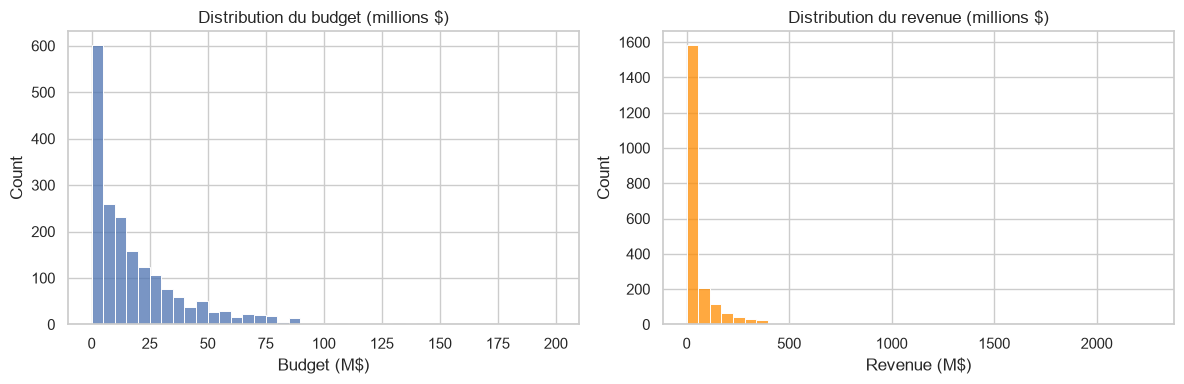

In [2]:
# distribution budget / revenue ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["budget"].dropna() / 1e6, bins=40, ax=axes[0])
axes[0].set_title("Distribution du budget (millions $)")
axes[0].set_xlabel("Budget (M$)")

sns.histplot(df["revenue"].dropna() / 1e6, bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution du revenue (millions $)")
axes[1].set_xlabel("Revenue (M$)")

plt.tight_layout()
plt.show()

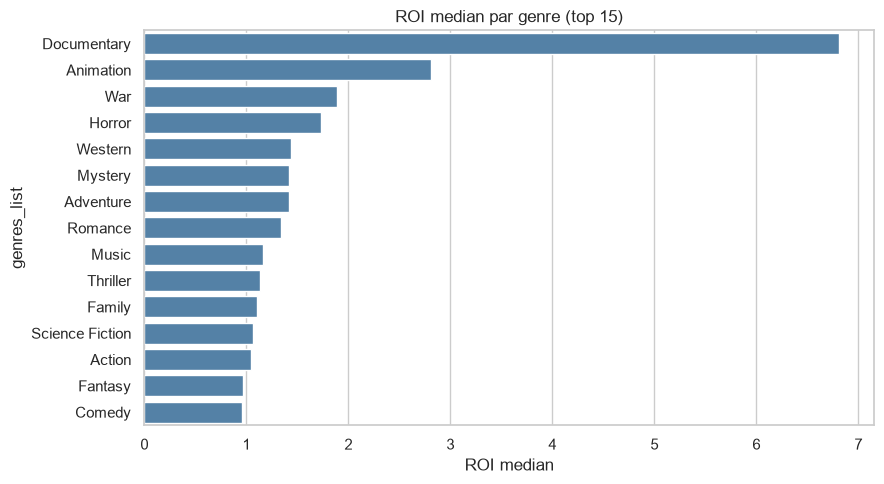

In [3]:
# ROI median par genre ---
df_genres = df.explode("genres_list").dropna(subset=["genres_list", "roi"])
roi_by_genre = (
    df_genres.groupby("genres_list")["roi"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=roi_by_genre.values, y=roi_by_genre.index, color="steelblue")
plt.title("ROI median par genre (top 15)")
plt.xlabel("ROI median")
plt.tight_layout()
plt.show()


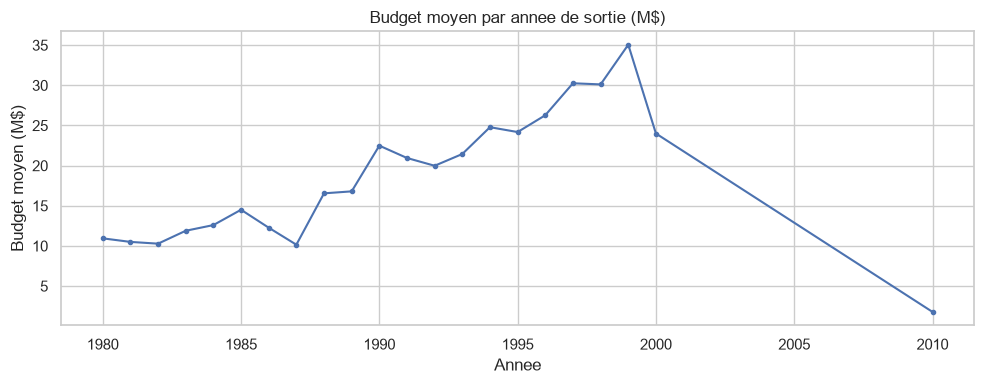

In [4]:

# evolution du budget moyen par annee ---
budget_by_year = (
    df.dropna(subset=["budget"])
    .groupby("release_year")["budget"]
    .mean()
    .div(1e6)
)
budget_by_year = budget_by_year[budget_by_year.index >= 1980]

plt.figure(figsize=(10, 4))
budget_by_year.plot(marker="o", markersize=3)
plt.title("Budget moyen par annee de sortie (M$)")
plt.ylabel("Budget moyen (M$)")
plt.xlabel("Annee")
plt.tight_layout()
plt.show()

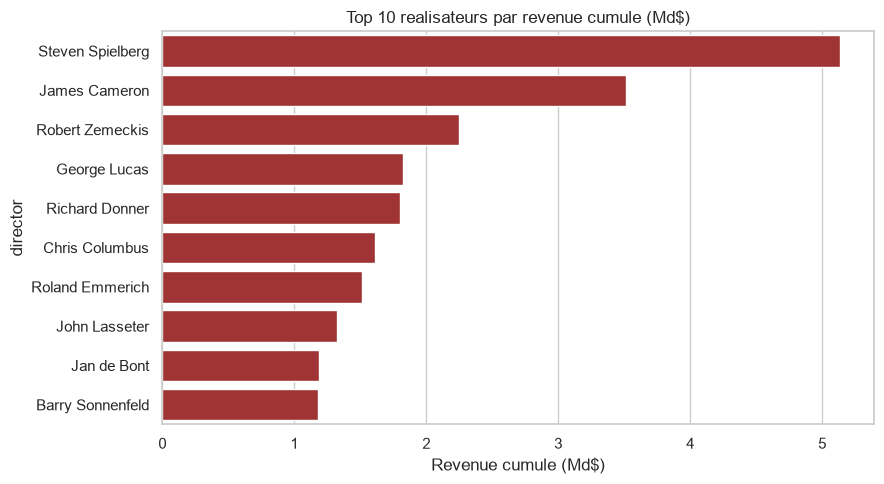

In [5]:
# top realisateurs par revenue cumule ---
top_directors = (
    df.dropna(subset=["revenue", "director"])
    .groupby("director")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .div(1e9)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_directors.values, y=top_directors.index, color="firebrick")
plt.title("Top 10 realisateurs par revenue cumule (Md$)")
plt.xlabel("Revenue cumule (Md$)")
plt.tight_layout()
plt.show()

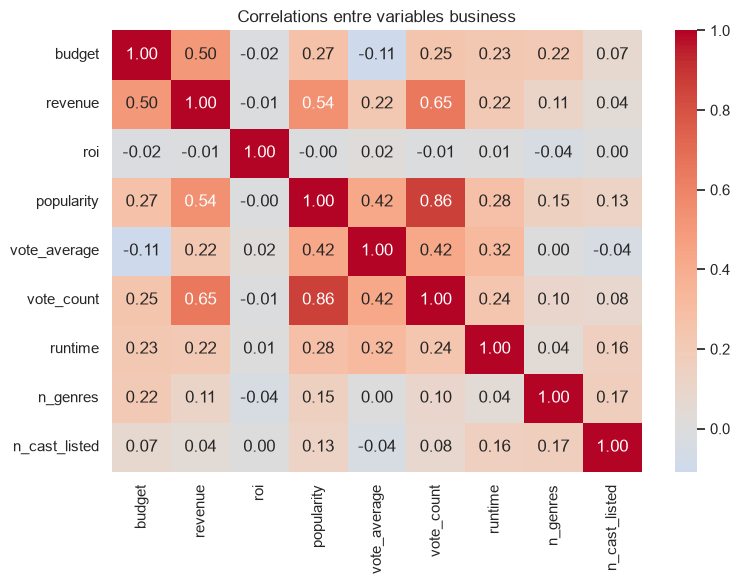

In [6]:
#heatmap correlations ---
num_cols = ["budget", "revenue", "roi", "popularity", "vote_average",
            "vote_count", "runtime", "n_genres", "n_cast_listed"]

corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations entre variables business")
plt.tight_layout()
plt.show()